In [19]:
"""
=========================================
SGOT example for a rotated linear system
=========================================

This notebook presents a synthetic example of Spectral Grassmannian-Wasserstein
Optimal Transport (SGOT) on linear dynamical systems.

We consider a signal formed by the sum of two damped oscillatory modes evolving
along a rotated direction in the plane. The signal is then associated with an
underlying continuous linear dynamical system, and we study how its spectral
representation varies under rotation. The SGOT cost and metric are used to
compare the reference and rotated systems.

[1] T. Germain; R. Flamary; V. R. Kostic; K. Lounici, A Spectral-Grassmann Wasserstein Metric for Operator Representations of Dynamical Systems, arXiv preprint arXiv:2509.24920, 2025.

"""

'\n=========================================\nSGOT example for a rotated linear system\n=========================================\n\nThis notebook presents a synthetic example of Spectral Grassmannian-Wasserstein\nOptimal Transport (SGOT) on linear dynamical systems.\n\nWe consider a signal formed by the sum of two damped oscillatory modes evolving\nalong a rotated direction in the plane. The signal is then associated with an\nunderlying continuous linear dynamical system, and we study how its spectral\nrepresentation varies under rotation. The SGOT cost and metric are used to\ncompare the reference and rotated systems.\n\n[1] T. Germain; R. Flamary; V. R. Kostic; K. Lounici, A Spectral-Grassmann Wasserstein Metric for Operator Representations of Dynamical Systems, arXiv preprint arXiv:2509.24920, 2025.\n\n'

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from ot.sgot import sgot_metric, sgot_cost_matrix

from scipy.linalg import eig

In [21]:
# sampling parameters and time grid
fs = 50
max_t = 5
time = np.linspace(0, max_t, fs * max_t)
dt = 1 / fs

# Example: rotating a linear dynamical system in 3D

## 1. Build a simple observed signal 

We begin by assuming that the observed signal is made of two oscillatory components:
$$
x(t)=e^{-\tau_1 t}\cos(2\pi\omega_1 t)\,\vec e(\theta)
\;+\;
e^{-\tau_2 t}\cos(2\pi\omega_2 t)\,\vec e(\theta),
$$
where $\vec e(\theta)\in\mathbb{R}^2$ is a fixed real vector. Thus, $x(t)$ evolves along the one-dimensional subspace spanned by $\vec e(\theta)$, while its time dependence exhibits oscillatory and dissipative behaviour.


In [22]:
tau_0 = np.array([0.08, 0.18])
freq_0 = np.array([1., 2.])
theta_0 = np.pi / 4

def generate_data(time,tau,freq,theta):
    t_ = np.sin(2 * np.pi * freq[None,:] * time[:,None]) * np.exp(-tau[None,:] * time[:,None])
    t_ = t_.sum(axis=1)
    traj_0 = np.zeros((t_.shape[0],2))
    traj_0[:,0] = t_
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    traj_0 = traj_0 @ rotation_matrix.T
    return traj_0
traj_0 = generate_data(time,tau_0,freq_0,theta_0)

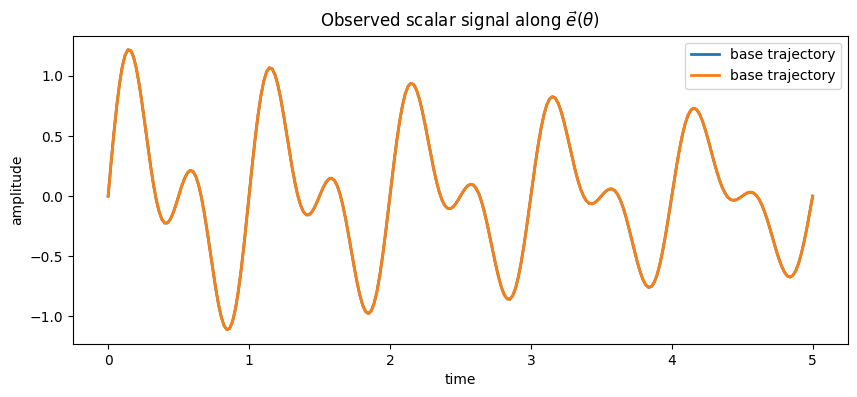

In [23]:
# plot the observed signal components and their sum
plt.figure(figsize=(10, 4))
plt.plot(time, traj_0, label="base trajectory", linewidth=2)
plt.xlabel("time")
plt.ylabel("amplitude")
plt.legend()
plt.title(r"Observed scalar signal along $\vec{e}(\theta)$")
plt.show()

## 2. Interpret the signal as coming from a continuous linear dynamical system
We assume that $x(t)$ is generated by an underlying continuous linear dynamical system. Since the observed signal is a superposition of two sinusoidal modes, the corresponding linear dynamics are naturally described by a fourth-order model. We therefore introduce the state vector
$$
z(t)=
\begin{pmatrix}
x_1(t)\\
x_2(t)\\
\vdots\\
x_1^{(3)}(t)\\
x_2^{(3)}(t)
\end{pmatrix}
\in\mathbb{R}^8.
$$
This allows us to rewrite the dynamics as a first-order linear system:
$$
\dot{z}(t)=Az(t),
$$
where $A\in\mathbb{R}^{8\times 8}$. Its solution is then given by
$$
z(t)=e^{tA}z_0.
$$

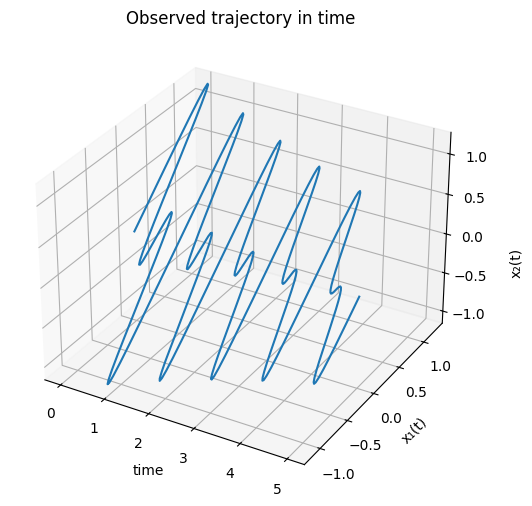

In [24]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(projection="3d")

ax.plot(time, traj_0[:, 0], traj_0[:, 1])
ax.set_xlabel("time")
ax.set_ylabel("x₁(t)")
ax.set_title("Observed trajectory in time")

ax.text2D(1.08, 0.5, "x₂(t)", transform=ax.transAxes, rotation=90, va="center")

plt.show()

## 3. Sampling and preprocessing discrete trajectories of dynamical system
We now have a bridge between the continuous system and the operator we later aim to infer from sampled data. Since in practice we do not observe the full continuous trajectory, we work instead with discrete samples of the signal. We take snapshots at uniform time intervals $\Delta t$, and write the sampled signal as

$$
S=
\begin{pmatrix}
x_1(0) & x_2(0)\\
x_1(\Delta t) & x_2(\Delta t)\\
\vdots\\
x_1(N\Delta t) & x_2(N\Delta t)\\
\end{pmatrix}
$$

The goal is now to use these observations to recover the operator governing the evolution.  
To do this, we augment the signal $s$ using a sliding window of length $w$. For each $k$, define
$$z_k =
\begin{pmatrix}
s_k\\
s_{k+1}\\
\vdots\\
s_{k+w-1}
\end{pmatrix}
$$
We then form the data matrices
$$
X=
\begin{pmatrix}
z_1\\
z_2\\
\vdots\\
z_{N-w}
\end{pmatrix},
\qquad
Y=
\begin{pmatrix}
z_2\\
z_3\\
\vdots\\
z_{N-w+1}
\end{pmatrix},
$$
so that $X$ contains the present windowed states and $Y$ the corresponding shifted future states.

In [25]:
# build a 4-dimensional state using delay embedding
def augment(traj, window_length = 2):
    Z = np.lib.stride_tricks.sliding_window_view(traj,(window_length,1))
    Z = Z.reshape(Z.shape[0], -1)
    return Z

# create the embedded state matrix Z
Z = augment(traj_0[:, [0]], 4)
Z.shape

# inspect one embedded state vector
Z[0]

# create X and Y for the SGOT metric
X = Z[:-1]
Y = Z[1:]

# inspect shapes of X and Y
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (246, 4)
Y shape: (246, 4)


## 4. Estimate the discrete-time operator
Now, we look to identify the operator that maps $X$ to $Y$. From
$$
\dot{z}=Az,
$$
we have
$$
z(t+\Delta t)=e^{\Delta tA}z(t).
$$
Setting
$$
B=e^{\Delta tA},
$$
the corresponding discrete-time evolution is governed by $B$, and we seek the best linear map satisfying
$$
Y\approx X B^T.
$$
Equivalently, we solve the optimisation problem
$$
\min_B \|Y-XB\|^2.
$$

We want to recover the best rank-$r$ operator, whose estimator is defined as follows
$$
B = C_{xx}^{-\frac{1}{2}}[C_{xx}^{-\frac{1}{2}}C_{xy}]_r \quad \text{s.t} \quad C_{xx} = X^T X \quad \text{and} \quad C_{xy} = X^TY.
$$
where $[ ]_r$ is the best rank-$r$ estimator through SVD decomposition. [2]

[2] Kostic, V., Novelli, P., Maurer, A., Ciliberto, C., Rosasco, L. and Pontil, M., 2022. Learning dynamical systems via Koopman operator regression in reproducing kernel Hilbert spaces. Advances in Neural Information Processing Systems, 35, pp.4017-4031.

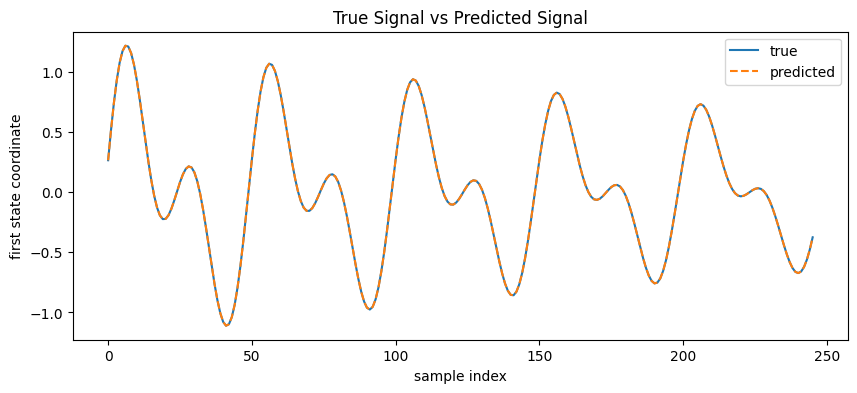

In [26]:
def estimator(X,Y,rank=4):
    # X: (n_samples, n_features)
    # Y: (n_samples, n_features)

    # estimate operator
    cxx = X.T @ X
    U, S, Vt = np.linalg.svd(cxx)
    S_inv = np.divide(1, S, out=np.zeros_like(S), where=S!=0)
    cxx_inv_half = Vt.T @ np.diag(np.sqrt(S_inv)) @ U.T
    cxy = X.T @ Y
    T = cxx_inv_half @ cxy
    U,S,Vt = np.linalg.svd(T)
    S[rank:] = 0
    T_rank = U @ np.diag(S) @ Vt
    T = cxx_inv_half @ T_rank

    # estimate spectral decomposition
    val, vl, vr = eig(T, left=True, right=True)
    sort_idx = np.argsort(np.abs(val))[::-1]
    val = val[sort_idx][:rank]
    vl = vl[:, sort_idx][:,:rank]
    vr = vr[:, sort_idx][:,:rank]
    
    return T, {"eig_val": val, "eig_vec_left": vl, "eig_vec_right": vr}

B_0, B_0_spec = estimator(X, Y, rank=4)
Y_pred = X @ B_0

plt.figure(figsize=(10, 4))
plt.plot(Y[:, 0], label="true")
plt.plot(Y_pred[:, 0], "--", label="predicted")
plt.xlabel("sample index")
plt.ylabel("first state coordinate")
plt.title("True Signal vs Predicted Signal")
plt.legend()
plt.show()

The predicted signal is nearly indistinguishable from the true signal, indicating that the estimated operator accurately captures the observed dynamics.

## 6. Recover continuous-time spectral information from the discrete operator
To recover the continuous generator $A$, we study the spectral structure of $B$. We diagonalise $B$ as
$$
B=PDP^{-1},
$$
where
$$
D=\operatorname{diag}(\mu_1,\dots,\mu_n).
$$
The continuous-time eigenvalues are of the form
$$
\lambda_k=-\tau_k+2\pi i\,\omega_k,
\qquad k\in\{1,2\},
$$
and the corresponding eigenvalues of $B$ are
$$
\mu_k=e^{\Delta t\lambda_k}
     =e^{\Delta t(-\tau_k+2\pi i\omega_k)}.
$$

Since $B=e^{\Delta tA}$, we recover $A$ by taking the logarithm:
$$
A=P\,\frac{\log(D)}{\Delta t}\,P^{-1}.
$$

In [27]:
D_0 = np.log(B_0_spec["eig_val"]) * fs
L_0 = B_0_spec["eig_vec_left"]
R_0 = B_0_spec["eig_vec_right"]

freq = D_0.imag / (2 * np.pi)
mask = freq > 0
freq = freq[mask]
decay = -D_0.real[mask]
print(f"First mode: frequency: {freq[0]:.2f} Hz -- decay: {decay[0]:.2f}")
print(f"Second mode: frequency: {freq[1]:.2f} Hz -- decay: {decay[1]:.2f}")

First mode: frequency: 1.00 Hz -- decay: 0.08
Second mode: frequency: 2.01 Hz -- decay: 0.18


## Applying a rotation in the notebook

The rotation is introduced through the parameter `theta`. In the data-generation step, the trajectory is rotated in the observation plane by the 2D rotation matrix

$$
R(\theta)=
\begin{pmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{pmatrix},
$$

via `traj_0 = traj_0 @ R(theta).T`.

At the operator level, the same transformation is represented by conjugation of the reference operator,

$$
A_{\mathrm{rot}} = P(\theta),A_{\mathrm{ref}},P(\theta)^\top,
$$

where $P(\theta)$ is the block rotation acting on both state coordinates and their derivatives.


In [36]:
# [X_1,X_2,X_1_,X_2_]
A_ref= np.array([[0,0,1,0],[0,0,0,0],[-1,0,0,0],[0,0,0,0]])

b = 0.1
c = 1
A_shift= np.array([[0,0,1,0],[0,0,0,0],[-c,0,-b,0],[0,0,0,0]])

def rotation_matrix(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s, 0, 0], [s, c, 0, 0], [0, 0, c, -s], [0, 0, s, c]])

P = rotation_matrix(np.pi/4)
A_rot = P @ A_ref @ P.T

A_ref_decomp = np.linalg.eig(A_ref)
A_rot_decomp = np.linalg.eig(A_rot)

# Introduction to SGOT for linear operators

To compare two linear operators through their spectral structure, we use the SGOT framework introduced in Theorem 1 of [1]. For a non-defective finite-rank operator $T \in S_r(\mathcal H)$, the theorem associates a discrete spectral measure

$$
\mu(T) \triangleq \sum_{j\in[\ell]} \frac{m_j}{m_{\mathrm{tot}}},\delta_{(\lambda_j,\mathcal V_j)},
$$

where $\lambda_j$ are the eigenvalues of $T$, $m_j$ their algebraic multiplicities, and $\mathcal V_j$ the corresponding eigenspaces. Thus, each spectral component of the operator is represented by an atom of the form

$$
(\lambda_j,\mathcal V_j),
$$

combining one eigenvalue with its associated invariant subspace.

Theorem 1 then defines a ground cost between two such atoms by combining a spectral discrepancy and a geometric discrepancy:

$$
d_\eta\big((\lambda,\mathcal V),(\lambda',\mathcal V')\big)
\triangleq
\eta,|\lambda-\lambda'| + (1-\eta), d_{\mathcal G}(\mathcal V,\mathcal V'),
$$

where $d_{\mathcal G}$ denotes the Grassmann distance between eigenspaces and $\eta\in(0,1)$ balances the contribution of eigenvalues and eigenspaces.

The SGOT distance between two operators $T$ and $T'$ is then the Wasserstein distance between their associated spectral measures:

$$
d_S(T,T') = W_{d_\eta,p}\big(\mu(T),\mu(T')\big).
$$

In this way, SGOT compares linear operators by optimally matching their spectral atoms, taking into account both the location of eigenvalues and the relative geometry of their eigenspaces.


In [37]:
thetas = np.linspace(0, np.pi, 10)
lst = []
for i, theta in enumerate(thetas):
    traj = generate_data(time, tau_0, freq_0, theta)
    Z = augment(traj[:, [0]], 4)
    X = Z[:-1]
    Y = Z[1:]
    B, B_spec = estimator(X, Y, rank=4)
    D, R, L = B_spec["eig_val"], B_spec["eig_vec_right"], B_spec["eig_vec_left"]
    D = np.log(D) * fs 
    lst.append(sgot_metric(D_0, R_0, L_0, D, R, L, eta=0.01))
    

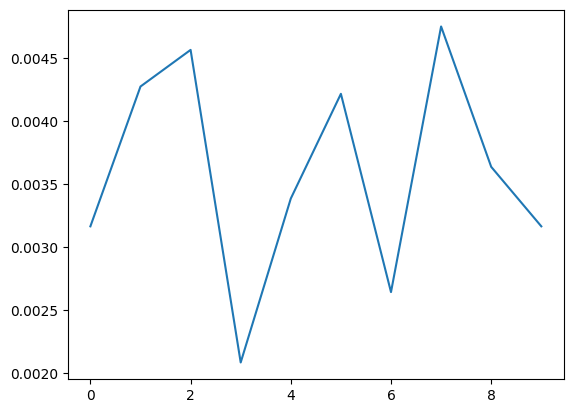

In [38]:
plt.plot(lst)

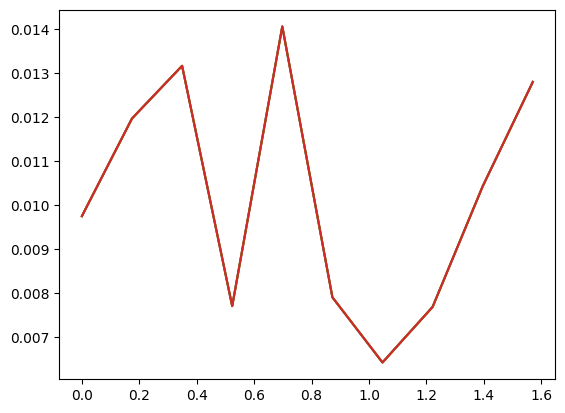

In [47]:
thetas = np.linspace(0, np.pi/2, 10)
lst = []
for i, theta in enumerate(thetas):
    traj = generate_data(time, tau_0, freq_0, theta)
    Z = augment(traj[:, [0]], 4)
    X = Z[:-1]
    Y = Z[1:]
    B, B_spec = estimator(X, Y, rank=4)
    D, R, L = B_spec["eig_val"], B_spec["eig_vec_right"], B_spec["eig_vec_left"]
    D = np.log(D) * fs 
    lst1 = []
    for name in ['chordal', 'martin', 'geodesic', 'procrustes']:
        lst1.append(sgot_metric(D_0, R_0, L_0, D, R, L, eta=0.9, grassman_metric=name))
    lst.append(lst1)
lst2 = np.array(lst)
plt.plot(thetas, lst2)
    

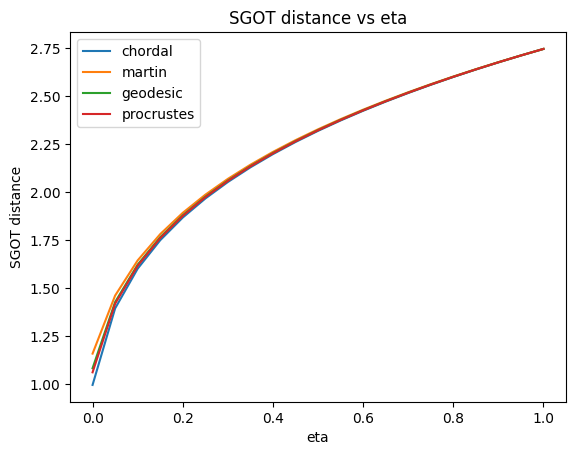

In [42]:
etas = np.linspace(0.0, 1.0, 21)
methods = ['chordal', 'martin', 'geodesic', 'procrustes']
scores_eta = []

for eta in etas:
    freq_1 = np.array([freq_0[0], freq])
    traj = generate_data(time, tau_0, freq_1, theta)
    Z = augment(traj[:, [0]], 4)
    X = Z[:-1]
    Y = Z[1:]

    B, B_spec = estimator(X, Y, rank=4)
    D, R, L = B_spec["eig_val"], B_spec["eig_vec_right"], B_spec["eig_vec_left"]
    D = np.log(D) * fs

    row = []
    for name in methods:
        row.append(
            sgot_metric(
                D_0, R_0, L_0,
                D, R, L,
                eta=eta,
                grassman_metric=name
            )
        )
    scores_eta.append(row)

scores_eta = np.array(scores_eta)

for i, name in enumerate(methods):
    plt.plot(etas, scores_eta[:, i], label=name)

plt.xlabel("eta")
plt.ylabel("SGOT distance")
plt.title("SGOT distance vs eta")
plt.legend()
plt.show()

In [2]:
decays = np.linspace(0.1, 3.0, 20)   # adjust range as needed
methods = ['chordal', 'martin', 'geodesic', 'procrustes']
scores_decay = []

for tau in decays:
    freq_1 = np.array([freq_0[0], freq])
    tau_1 = np.array([tau, tau])  # or whatever structure your generator expects

    traj = generate_data(time, tau_1, freq_1, theta)
    Z = augment(traj[:, [0]], 4)
    X = Z[:-1]
    Y = Z[1:]

    B, B_spec = estimator(X, Y, rank=4)
    D, R, L = B_spec["eig_val"], B_spec["eig_vec_right"], B_spec["eig_vec_left"]
    D = np.log(D) * fs

    row = []
    for name in methods:
        row.append(
            sgot_metric(
                D_0, R_0, L_0,
                D, R, L,
                eta=0.9,   # keep eta fixed here
                grassman_metric=name
            )
        )
    scores_decay.append(row)

scores_decay = np.array(scores_decay)

for i, name in enumerate(methods):
    plt.plot(decays, scores_decay[:, i], label=name)

plt.xlabel("decay")
plt.ylabel("SGOT distance")
plt.title("SGOT distance vs decay")
plt.legend()
plt.show()

NameError: name 'np' is not defined